# Evaluation on the DeepWings test set (external, out-of-domain)

Our own `val`/`test` splits (used everywhere else, e.g. notebook 25) come from
the same collection pipeline the model trains on -- same cameras, same
cropping convention, same labeling process. This notebook instead runs our
model on **DeepWings'** own test set
(`C:/Users/X/projects/deepwings/test` + `test_masks`, from the
[Beeapp-landmark-detection](https://www.mdpi.com/2504-2289/6/3/70) project,
3510 `.jpg` images -- a handful of `.bmp` files also present in that folder
are skipped, see Setup), an independently collected dataset our model has
never seen during training, to check how well it generalizes beyond its own
data pipeline. Preliminary exploration already confirmed our model *can* run
on these images (notebook 21); this notebook measures *how accurately*,
against DeepWings' own ground-truth landmark masks.

**Same two accuracy numbers as notebook 25, for the same reason -- but here
*both* sides need GPA ordering, not just the prediction:**
- **GPA-ordered** (`gpa_ordered_distances`) -- our own dataset's ground truth
  comes from a precise, already-ordered coordinate CSV, so only the
  *prediction* needed GPA reordering there. DeepWings only gives us a
  *mask image* for ground truth too (`test_masks/*`, dots with no identity),
  so here **both** the prediction and the ground truth are unordered point
  sets decoded the same way (`mask_to_coords`) and both need independent GPA
  ordering against `mean_coords` before they can be compared index-wise.
  This is still production-realistic on the *prediction* side (no peeking at
  the other side to help order it) -- ordering the ground truth against the
  same fixed external reference isn't "cheating," it's the only way to give
  mask-decoded dots an identity at all.
- **Nearest-neighbor** (`nn_matched_distances`) -- diagnostic-only direct
  Hungarian match between predicted and ground-truth points in shared pixel
  space, ignoring identity. Tells apart "detection is off" from "GPA
  ordering is confused" by comparing the two numbers, exactly as in
  notebook 25.

**Horizontal flip:** DeepWings' images are pre-flipped (`cv2.flip(.., 1)`)
before being fed to the model, and their ground-truth masks are flipped the
same way before decoding, so both sides stay in a consistent (if mirrored)
frame -- carried over from notebook 21's preliminary exploration, and
re-verified below (Section A) rather than taken on faith: on a 60-image
sample, the flipped orientation gives a plausible predicted point count
(17-22, close to the true 19) for 45/60 images vs. 36/60 unflipped. This is
now just a *detection-quality* choice, not a correctness requirement --
`allow_reflection=True` (see `wings/gpa.py`) means a genuinely mirrored
prediction would still get matched to the right landmark identities either
way -- but the model itself apparently segments DeepWings' wings more
reliably in this orientation.

## Setup

In [12]:
import random
import time
from functools import partial
from pathlib import Path

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from scipy.spatial import procrustes
from scipy.spatial.distance import cdist, pdist, squareform
from tqdm.notebook import tqdm

from wings.config import PROCESSED_DATA_DIR, MODELS_DIR
from wings.utils import load_image
from wings.visualizing.image_preprocess import unet_fit_rectangle_preprocess, final_coords, mask_to_coords
from wings.gpa import handle_coordinates, FULL_ROTATION_MULTISTART_ANGLES
from wings.modeling.unet import UNet
from wings.modeling.litnet import LitNet
from wings.modeling.loss import BCEDiceLoss

torch.manual_seed(0)

# --- Update these two to point at a different checkpoint (e.g. a future config 4b) ---
CHECKPOINT_PATH = MODELS_DIR / "online" / "last.ckpt"  # config 4's trained checkpoint
MODEL_SIGMOID = False  # config 4 uses BCEDiceLoss -> UNet(sigmoid=False); flip to True for a config 1/3 checkpoint
# ---------------------------------------------------------------------------------------

OUTPUT_SIZE = 400
DEEPWINGS_DIR = Path(r"C:\Users\X\projects\deepwings")
TEST_DIR = DEEPWINGS_DIR / "test"
MASK_DIR = DEEPWINGS_DIR / "test_masks"

# Cap for the full quantitative run (Section C) -- None runs all matched pairs
# (~3510 images, ~20-25 minutes single-threaded on this machine, dominated by
# handle_coordinates's CPU-bound matching, not GPU inference). Set to a few
# hundred for faster iteration while developing this notebook.
MAX_SAMPLES = None

## Load model + mean shape

In [13]:
mean_coords = torch.load(
    PROCESSED_DATA_DIR / "mask_datasets" / "rectangle" / "mean_shape.pth", weights_only=False
)

model = UNet(in_channels=1, out_channels=1, kernel_size=5, sigmoid=MODEL_SIGMOID)
lit_net = LitNet.load_from_checkpoint(
    CHECKPOINT_PATH,
    model=model,
    criterion=BCEDiceLoss(),  # unused for inference, LitNet just requires one
    num_epochs=1,
    mean_coords=mean_coords,
    strict=False,
)
lit_net.eval()
device = lit_net.device
print(f"Loaded checkpoint: {CHECKPOINT_PATH.name}")

Loaded checkpoint: last.ckpt


## Discover DeepWings test files

DeepWings' `test/` folder is mostly `.jpg` (3510 files) plus a handful of
`.bmp` files (21) that are skipped here -- few enough not to be worth the
extra handling (`torchvision.io.decode_image`, used by `wings.utils.load_image`
below, can't decode `.bmp` at all: "Only jpeg, png, webp and gif are currently
supported").

In [14]:
exts = (".jpg", ".jpeg")
all_files = list(TEST_DIR.iterdir())
test_files = sorted(p for p in all_files if p.suffix.lower() in exts)
skipped = sorted(p for p in all_files if p.suffix.lower() not in exts)
mask_files = {p.name: p for p in MASK_DIR.iterdir() if p.suffix.lower() in exts}

pairs = [(p, mask_files[p.name]) for p in test_files if p.name in mask_files]
missing = [p for p in test_files if p.name not in mask_files]

print(f"Test images found: {len(test_files)} (skipped {len(skipped)} non-jpg files, e.g. .bmp)")
print(f"Matched image/mask pairs: {len(pairs)}")
if missing:
    print(f"Missing masks for {len(missing)} images:")
    for p in missing[:10]:
        print(" ", p.name)

Test images found: 3510 (skipped 21 non-jpg files, e.g. .bmp)
Matched image/mask pairs: 3510


## Helper functions

In [15]:
preprocess = partial(unet_fit_rectangle_preprocess, output_size=OUTPUT_SIZE)


def predict_coords(image_path):
    """Runs one DeepWings image through the model, via the same
    wings.utils.load_image used in production (EXIF-orientation-corrected
    grayscale decode + unet_fit_rectangle_preprocess). Flips horizontally
    first (see intro markdown) -- the predicted points come back in that same
    flipped 400x400 pixel space (bottom-left convention, same as
    mask_to_coords everywhere else), NOT the true unflipped original, which
    is fine as long as the ground truth below is flipped the same way."""
    image, x_size, y_size = load_image(image_path, preprocess)
    image = torch.flip(image, dims=[-1])
    with torch.no_grad():
        output = lit_net.model(image.unsqueeze(0).to(device))
    probs = output if MODEL_SIGMOID else torch.sigmoid(output)
    mask = (probs > 0.5).float().squeeze().cpu().numpy()
    return final_coords(mask, x_size, y_size), image


def ground_truth_coords(mask_path):
    """Decodes DeepWings' own ground-truth mask into points -- flipped the
    same way as predict_coords, and otherwise identical in spirit to how a
    predicted mask is decoded (mask_to_coords): these dots carry no landmark
    identity either, they're just rendered circles (see DeepWings' own
    cria_mascara.py), so they need GPA ordering just like a prediction does."""
    img = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    img = cv2.flip(img, 1)
    return mask_to_coords(img.astype(np.float32) / 255.0)


def gpa_order(coords):
    """GPA-orders an unordered point set against mean_coords.
    allow_reflection=True + multistart_angles: see wings/gpa.py -- DeepWings'
    photography setup/crop convention is unrelated to ours, so nothing
    guarantees predictions land at a small rotation offset from mean_coords'
    own orientation the way our in-domain eval images do."""
    if len(coords) == 0:
        return None
    t = torch.tensor(coords, dtype=torch.float32)
    return handle_coordinates(t, mean_coords, allow_reflection=True, multistart_angles=FULL_ROTATION_MULTISTART_ANGLES)


def wing_positional_precision(gt, pred):
    """DeepWings' own "metric 2" (notebook 20) -- reported in their paper as
    an average positional precision of 0.943. gt/pred are (19, 2) arrays of
    *corresponding* landmarks (same landmark index = same landmark on both
    sides, exactly what GPA ordering above guarantees). Superimposes both
    shapes via Procrustes (centered, unit-scale, pred optimally rotated onto
    gt), takes every pairwise inter-landmark distance within each shape, and
    scores each of the 342 off-diagonal pairs as min(d_gt, d_pred) /
    max(d_gt, d_pred) -- 1.0 means the two shapes' pairwise geometry is
    identical. Unlike the pixel-error metrics above, this is translation/
    scale/rotation-invariant: it asks "is the shape right" rather than "are
    the points in the right place." Returns (wing_precision, per_landmark)."""
    mtx_gt, mtx_pred, _ = procrustes(np.asarray(gt, float), np.asarray(pred, float))
    d_gt = squareform(pdist(mtx_gt))
    d_pred = squareform(pdist(mtx_pred))
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.minimum(d_gt, d_pred) / np.maximum(d_gt, d_pred)
    np.fill_diagonal(ratio, np.nan)
    return np.nanmean(ratio), np.nanmean(ratio, axis=1)


def gpa_ordered_metrics(pred_coords, gt_coords):
    """GPA-orders both sides ONCE and derives everything from that single
    pass: per-point pixel distances (production-realistic accuracy, see
    intro) and DeepWings' positional-precision score above -- computing both
    from the same pred_o/gt_o avoids paying for GPA ordering twice. Returns
    (distances, precision), either half None/nan if ordering failed on
    either side (empty prediction or ground truth) or scipy.procrustes
    rejected a degenerate (all-identical) shape."""
    pred_o, gt_o = gpa_order(pred_coords), gpa_order(gt_coords)
    if pred_o is None or gt_o is None:
        return None, float("nan")
    dist = torch.norm(pred_o - gt_o, dim=1)
    try:
        precision, _ = wing_positional_precision(gt_o.numpy(), pred_o.numpy())
    except ValueError:
        precision = float("nan")
    return dist, precision


def gpa_ordered_distances(pred_coords, gt_coords):
    """Production-realistic accuracy -- see intro markdown for why *both*
    sides need GPA ordering here, unlike notebook 25."""
    dist, _ = gpa_ordered_metrics(pred_coords, gt_coords)
    return dist


def nn_matched_distances(pred_coords, gt_coords):
    """Diagnostic-only direct Hungarian match in shared pixel space,
    ignoring identity -- see intro markdown. Matches min(len(pred), len(gt))
    pairs."""
    if len(pred_coords) == 0 or len(gt_coords) == 0:
        return None
    cost = cdist(np.array(gt_coords), np.array(pred_coords))
    row, col = linear_sum_assignment(cost)
    return torch.from_numpy(cost[row, col]).float()


def to_plot_xy(coords, img_size):
    """bottom-left (x, y) -> top-left, for correct overlay on an imshow."""
    return [(x, img_size - y - 1) for x, y in coords]


def overlay(ax, image, pred_coords, gt_coords, title):
    img_size = image.shape[-1]
    ax.imshow(image.squeeze(0).numpy(), cmap="gray")
    if gt_coords:
        gx, gy = zip(*to_plot_xy(gt_coords, img_size))
        ax.scatter(gx, gy, s=160, facecolors="none", edgecolors="lime", linewidths=2.2, label="DeepWings ground truth")
    if pred_coords:
        px, py = zip(*to_plot_xy(pred_coords, img_size))
        ax.scatter(px, py, c="red", s=90, marker="x", linewidths=2.2, label="predicted")
    ax.set_title(f"{title} (gt={len(gt_coords)}, pred={len(pred_coords)})", fontsize=13)
    ax.legend(loc="upper right", fontsize=10)
    ax.axis("off")


def show_one(image, pred_coords, gt_coords, title):
    fig, ax = plt.subplots(figsize=(9, 9))
    overlay(ax, image, pred_coords, gt_coords, title)
    plt.tight_layout()
    plt.show()


def evaluate_pair(image_path, mask_path):
    """Runs one image through the full pipeline, returning a dict of
    per-image stats plus the raw coords/image (for visualization). Returns
    None/nan for metric entries that couldn't be computed (empty prediction
    or ground truth)."""
    pred_coords, image = predict_coords(image_path)
    gt_coords = ground_truth_coords(mask_path)
    gpa_dist, precision = gpa_ordered_metrics(pred_coords, gt_coords)
    nn_dist = nn_matched_distances(pred_coords, gt_coords)
    return {
        "path": image_path,
        "mask_path": mask_path,
        "n_pred": len(pred_coords),
        "n_gt": len(gt_coords),
        "gpa_dist": gpa_dist,
        "precision": precision,
        "nn_dist": nn_dist,
        "pred_coords": pred_coords,
        "gt_coords": gt_coords,
        "image": image,
    }


def result_title(name, result):
    gpa_str = f"{result['gpa_dist'].mean().item():.1f}px" if result["gpa_dist"] is not None else "n/a"
    prec_str = f"{result['precision']:.3f}" if not np.isnan(result["precision"]) else "n/a"
    nn_str = f"{result['nn_dist'].mean().item():.1f}px" if result["nn_dist"] is not None else "n/a"
    return f"{name} -- GPA={gpa_str}, precision={prec_str}, NN={nn_str}"

## Section A -- quick visual sanity check

A handful of fixed samples, checked by eye before committing to the full
3500+ image run below.

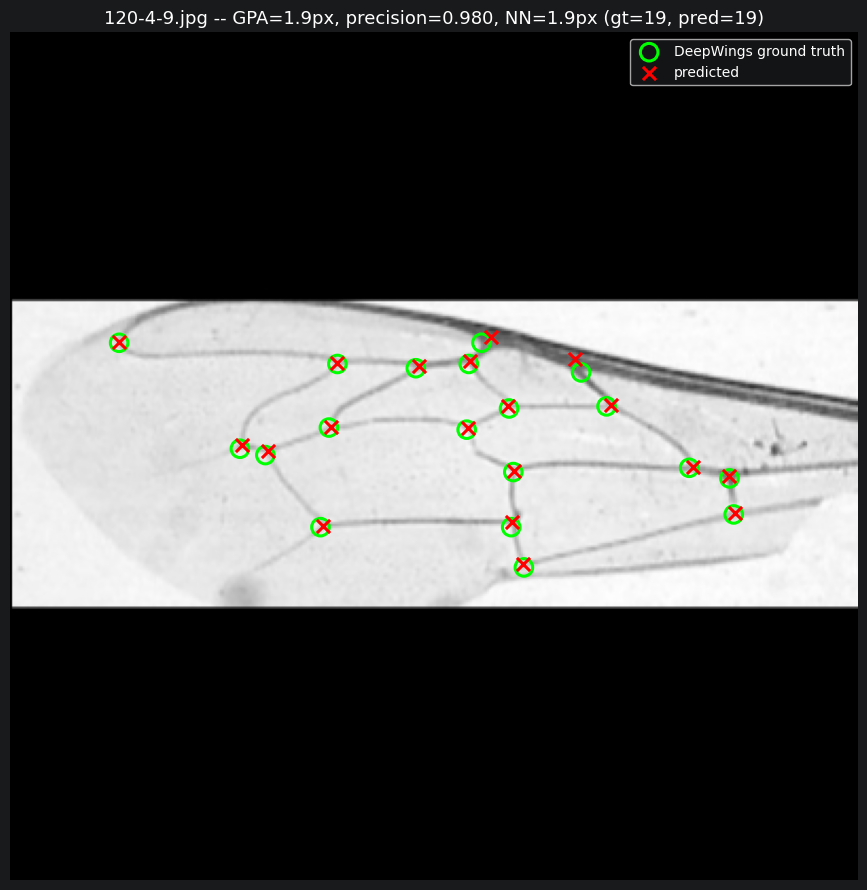

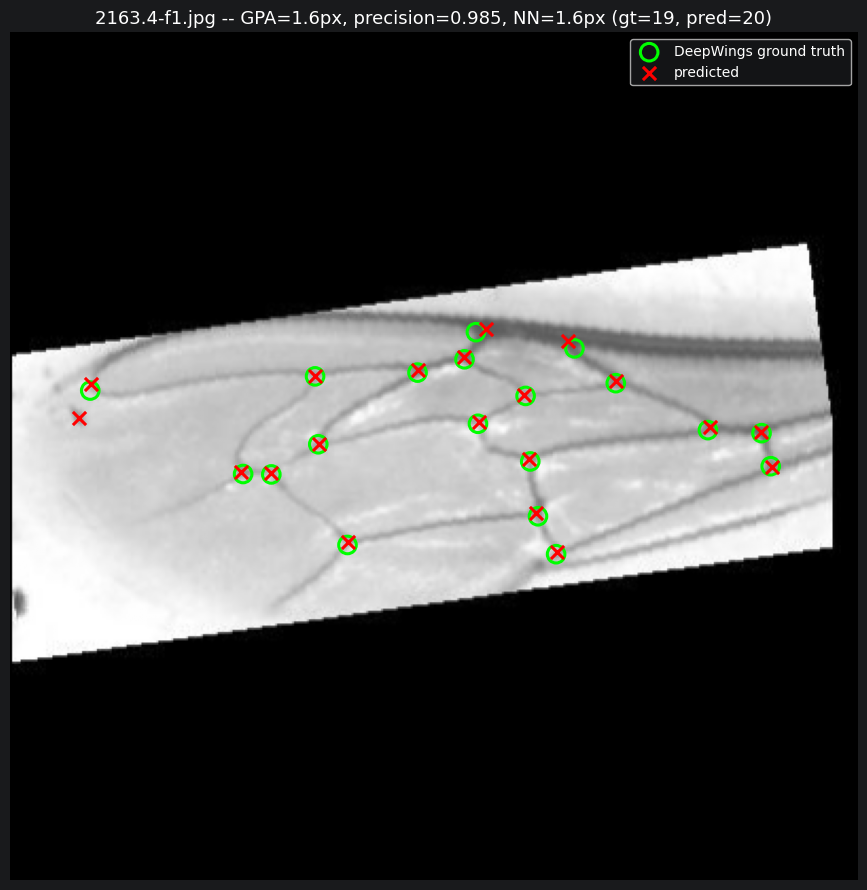

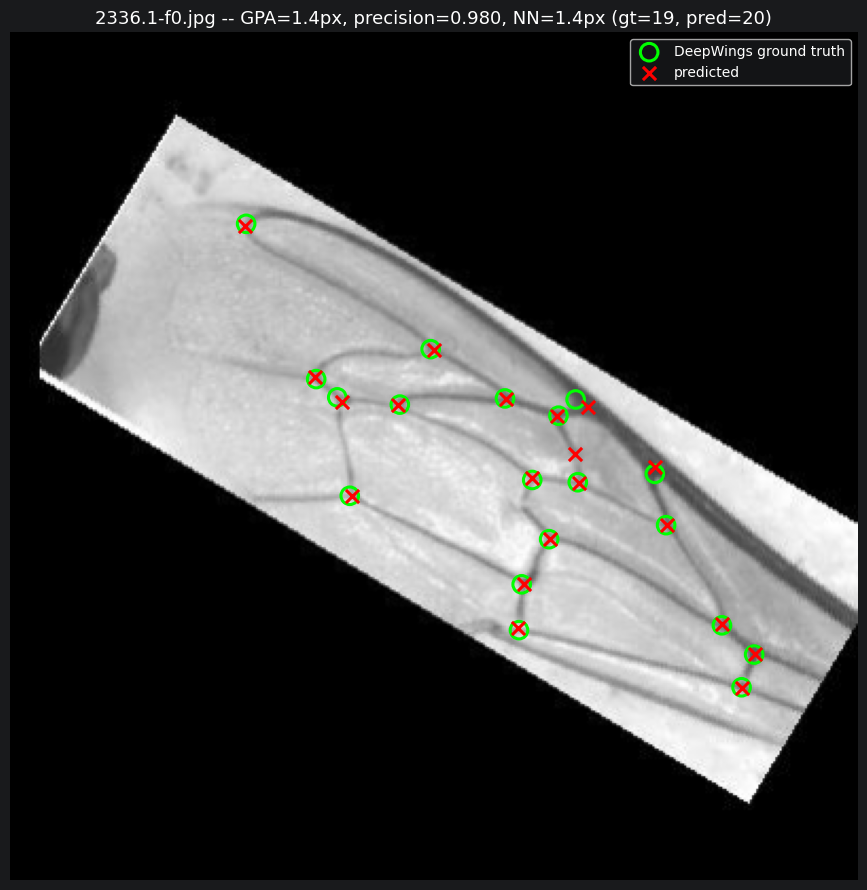

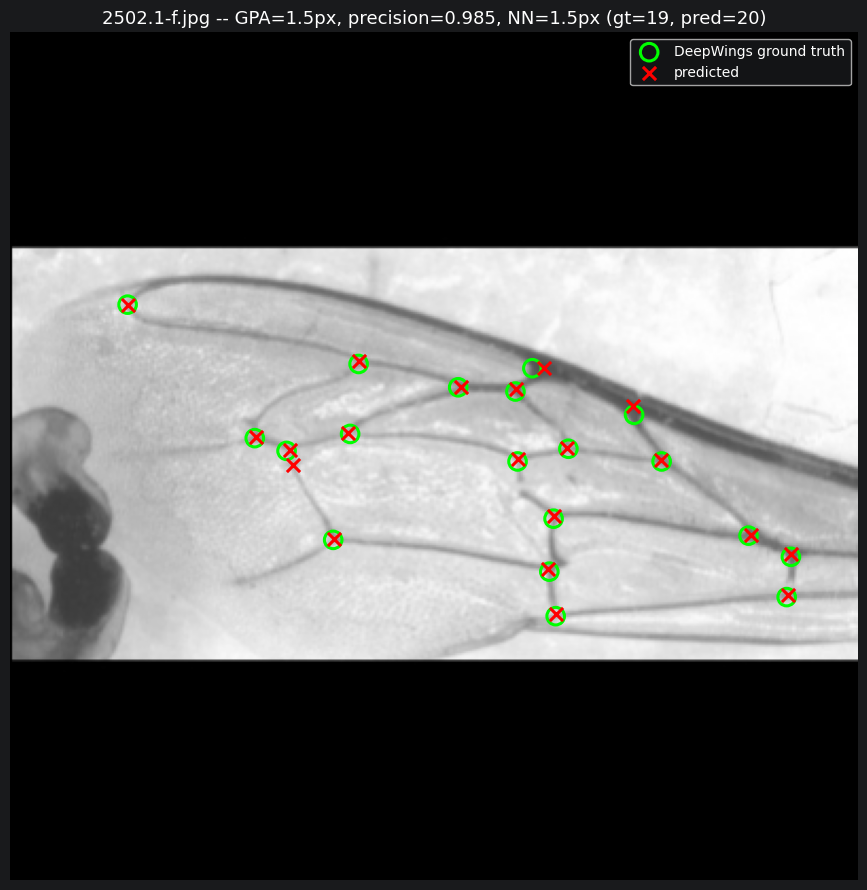

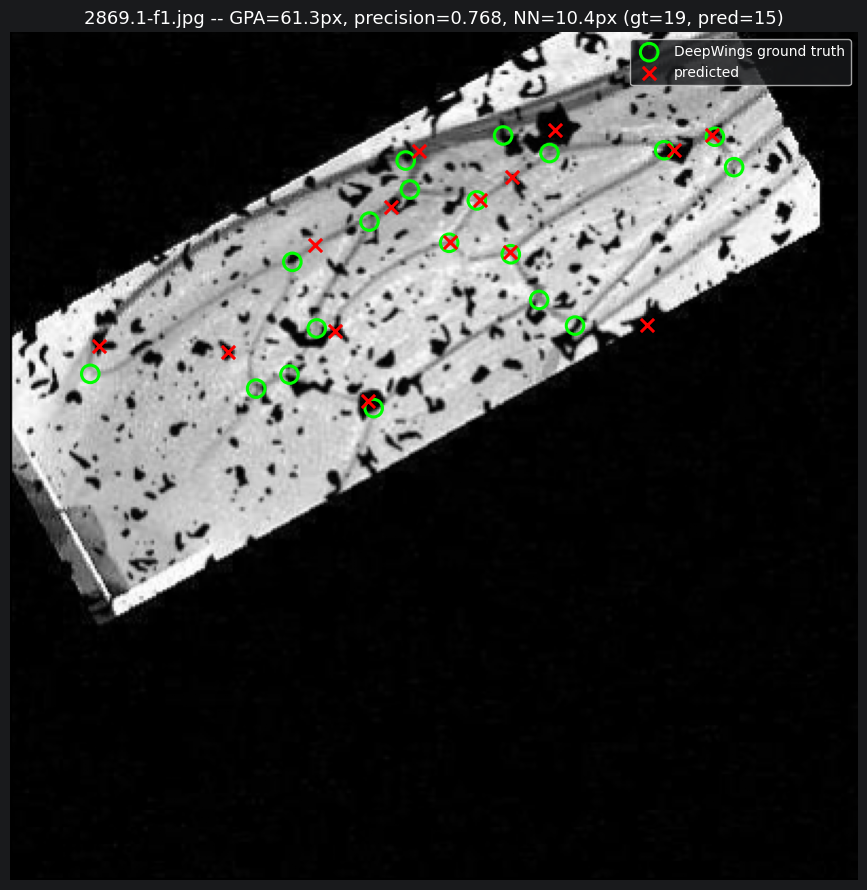

In [16]:
sanity_indices = [0, 500, 1000, 1500, 2000]
for idx in sanity_indices:
    path, mask_path = pairs[idx]
    result = evaluate_pair(path, mask_path)
    show_one(result["image"], result["pred_coords"], result["gt_coords"], result_title(path.name, result))

## Section B -- flip vs. no-flip, does it actually matter here?

Re-verifying notebook 21's flip choice directly (see intro markdown) rather
than taking it on faith: predicted point count on a 60-image sample, with
vs. without the pre-flip. Closer to 19 (and inside a plausible 17-22 band)
means a more confident, cleaner segmentation.

In [17]:
def predict_point_count(image_path, flip):
    image, x_size, y_size = load_image(image_path, preprocess)
    if flip:
        image = torch.flip(image, dims=[-1])
    with torch.no_grad():
        output = lit_net.model(image.unsqueeze(0).to(device))
    probs = output if MODEL_SIGMOID else torch.sigmoid(output)
    mask = (probs > 0.5).float().squeeze().cpu().numpy()
    return len(final_coords(mask, x_size, y_size))


random.seed(0)
flip_check_sample = random.sample(pairs, 60)
counts_flip, counts_noflip = [], []
for path, _ in tqdm(flip_check_sample, desc="flip vs. no-flip"):
    counts_noflip.append(predict_point_count(path, flip=False))
    counts_flip.append(predict_point_count(path, flip=True))

counts_flip, counts_noflip = np.array(counts_flip), np.array(counts_noflip)
for label, counts in [("no flip", counts_noflip), ("flip (used below)", counts_flip)]:
    good = ((counts >= 17) & (counts <= 22)).sum()
    print(f"{label:20s}  mean={counts.mean():5.1f}  median={np.median(counts):5.1f}  "
          f"in[17,22]={good}/{len(counts)}  range=[{counts.min()},{counts.max()}]")

flip vs. no-flip:   0%|          | 0/60 [00:00<?, ?it/s]

no flip               mean= 20.3  median= 19.0  in[17,22]=40/60  range=[8,35]
flip (used below)     mean= 21.0  median= 19.0  in[17,22]=39/60  range=[4,38]


## Section C -- full quantitative evaluation

Runs every matched image/mask pair through `gpa_ordered_metrics` (capped at
`MAX_SAMPLES` if set above). This is the main result: how accurately does
the model, trained only on our own data pipeline, locate landmarks on an
independently collected dataset it has never seen -- both as raw pixel error
and as DeepWings' own positional-precision score (`wing_positional_precision`,
paper value 0.943), so the number is comparable to both notebook 25's
in-domain baseline and to the paper's own headline metric. Point-count
buckets are tracked alongside both -- `handle_coordinates` handles up to +/-3
extra/missing points through its combinatorial correction search (16-22
predicted points here, since our landmark count is 19), and falls back to a
much cruder truncate/pad heuristic outside that range, so a sample outside
[16, 22] is a real detection failure, not just noise, and is worth seeing
separately from the headline numbers rather than silently averaged in (the
headline numbers still include it, matching how litnet.py's own val/test
metrics are computed, for a fair comparison to notebook 25's in-domain
numbers).

In [18]:
sample_pairs = pairs if MAX_SAMPLES is None else pairs[:MAX_SAMPLES]
print(f"Evaluating {len(sample_pairs)} image/mask pairs...")

t_start = time.time()
gpa_all, nn_all = [], []
per_image = []  # (path, mask_path, n_pred, n_gt, gpa_mean, nn_mean, precision) for Section D/E

for path, mask_path in tqdm(sample_pairs, desc="DeepWings evaluation"):
    pred_coords, _ = predict_coords(path)
    gt_coords = ground_truth_coords(mask_path)
    gpa_dist, precision = gpa_ordered_metrics(pred_coords, gt_coords)
    nn_dist = nn_matched_distances(pred_coords, gt_coords)

    if gpa_dist is not None:
        gpa_all.append(gpa_dist)
    if nn_dist is not None:
        nn_all.append(nn_dist)

    per_image.append({
        "path": path,
        "mask_path": mask_path,
        "n_pred": len(pred_coords),
        "n_gt": len(gt_coords),
        "gpa_mean": gpa_dist.mean().item() if gpa_dist is not None else float("nan"),
        "nn_mean": nn_dist.mean().item() if nn_dist is not None else float("nan"),
        "precision": precision,
    })

elapsed = time.time() - t_start
print(f"Done in {elapsed/60:.1f} minutes ({elapsed/len(sample_pairs)*1000:.0f} ms/image)")

Evaluating 3510 image/mask pairs...


DeepWings evaluation:   0%|          | 0/3510 [00:00<?, ?it/s]

Done in 18.1 minutes (310 ms/image)


In [19]:
gpa_cat = torch.cat(gpa_all) if gpa_all else torch.tensor([])
nn_cat = torch.cat(nn_all) if nn_all else torch.tensor([])
precision_arr = np.array([r["precision"] for r in per_image])

n_pred_arr = np.array([r["n_pred"] for r in per_image])
n_gt_arr = np.array([r["n_gt"] for r in per_image])
reliable = (n_pred_arr >= 16) & (n_pred_arr <= 22)

print(f"Samples evaluated: {len(per_image)}")
print(f"Predicted point count in [16, 22] (reliable range): {reliable.sum()} / {len(per_image)} ({100 * reliable.mean():.1f}%)")
print(f"Ground truth point count in [16, 22]: {((n_gt_arr >= 16) & (n_gt_arr <= 22)).sum()} / {len(per_image)}")
print()
print(f"{'metric':22s} {'mean':>8s} {'median':>8s} {'p90':>8s} {'n_points':>10s}")
for label, cat in [("GPA-ordered (all)", gpa_cat), ("nearest-neighbor (all)", nn_cat)]:
    if len(cat) == 0:
        print(f"{label:22s} {'n/a':>8s}")
        continue
    print(f"{label:22s} {cat.mean().item():8.3f} {cat.median().item():8.3f} "
          f"{cat.quantile(0.9).item():8.3f} {len(cat):10d}")

print()
print(f"Positional precision, ALL wings (DeepWings 'metric 2', 1.0=perfect, paper reports 0.943): "
      f"mean={np.nanmean(precision_arr):.4f}  median={np.nanmedian(precision_arr):.4f}  (n={np.sum(~np.isnan(precision_arr))})")

# All three metrics, restricted to the "reliable" point-count subset -- isolates
# ordering/generalization accuracy from raw detection-count failures.
print()
print("Restricted to samples with 16-22 predicted points:")
gpa_rel_list, nn_rel_list = [], []
for r, ok in zip(per_image, reliable):
    if not ok:
        continue
    if not np.isnan(r["gpa_mean"]):
        gpa_rel_list.append(r["gpa_mean"])
    if not np.isnan(r["nn_mean"]):
        nn_rel_list.append(r["nn_mean"])
precision_reliable = precision_arr[reliable]
print(f"  GPA-ordered per-image mean: avg={np.mean(gpa_rel_list):.3f}px  median={np.median(gpa_rel_list):.3f}px  (n={len(gpa_rel_list)})")
print(f"  nearest-neighbor per-image mean: avg={np.mean(nn_rel_list):.3f}px  median={np.median(nn_rel_list):.3f}px  (n={len(nn_rel_list)})")
print(f"  positional precision: mean={np.nanmean(precision_reliable):.4f}  median={np.nanmedian(precision_reliable):.4f}  (n={np.sum(~np.isnan(precision_reliable))})")

Samples evaluated: 3510
Predicted point count in [16, 22] (reliable range): 2436 / 3510 (69.4%)
Ground truth point count in [16, 22]: 3510 / 3510

metric                     mean   median      p90   n_points
GPA-ordered (all)        36.710    3.592  108.915      66690
nearest-neighbor (all)   10.083    1.566   34.810      63699

Positional precision, ALL wings (DeepWings 'metric 2', 1.0=perfect, paper reports 0.943): mean=0.8699  median=0.8589  (n=3510)

Restricted to samples with 16-22 predicted points:
  GPA-ordered per-image mean: avg=18.098px  median=1.898px  (n=2436)
  nearest-neighbor per-image mean: avg=8.666px  median=1.853px  (n=2436)
  positional precision: mean=0.9196  median=0.9790  (n=2436)


## Section D -- error distribution

Per-image mean GPA-ordered error, histogrammed -- shows whether the model is
consistently decent with a long tail of hard cases, or bimodal (mostly good,
some outright failures).

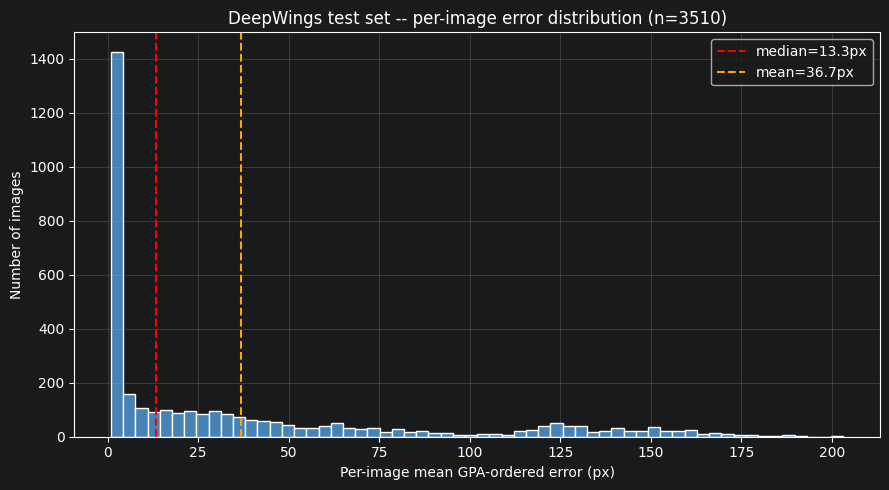

In [20]:
gpa_means = np.array([r["gpa_mean"] for r in per_image if not np.isnan(r["gpa_mean"])])

plt.figure(figsize=(9, 5))
plt.hist(gpa_means, bins=60, color="steelblue", edgecolor="white")
plt.axvline(np.median(gpa_means), color="red", linestyle="--", label=f"median={np.median(gpa_means):.1f}px")
plt.axvline(np.mean(gpa_means), color="orange", linestyle="--", label=f"mean={np.mean(gpa_means):.1f}px")
plt.xlabel("Per-image mean GPA-ordered error (px)")
plt.ylabel("Number of images")
plt.title(f"DeepWings test set -- per-image error distribution (n={len(gpa_means)})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section E -- worst offenders

The images with the highest GPA-ordered error, re-run individually for a
closer look -- useful for telling apart genuine model weaknesses from data
issues specific to DeepWings (compression artifacts merging two landmark
dots into one contour, an unusual wing crop, etc).

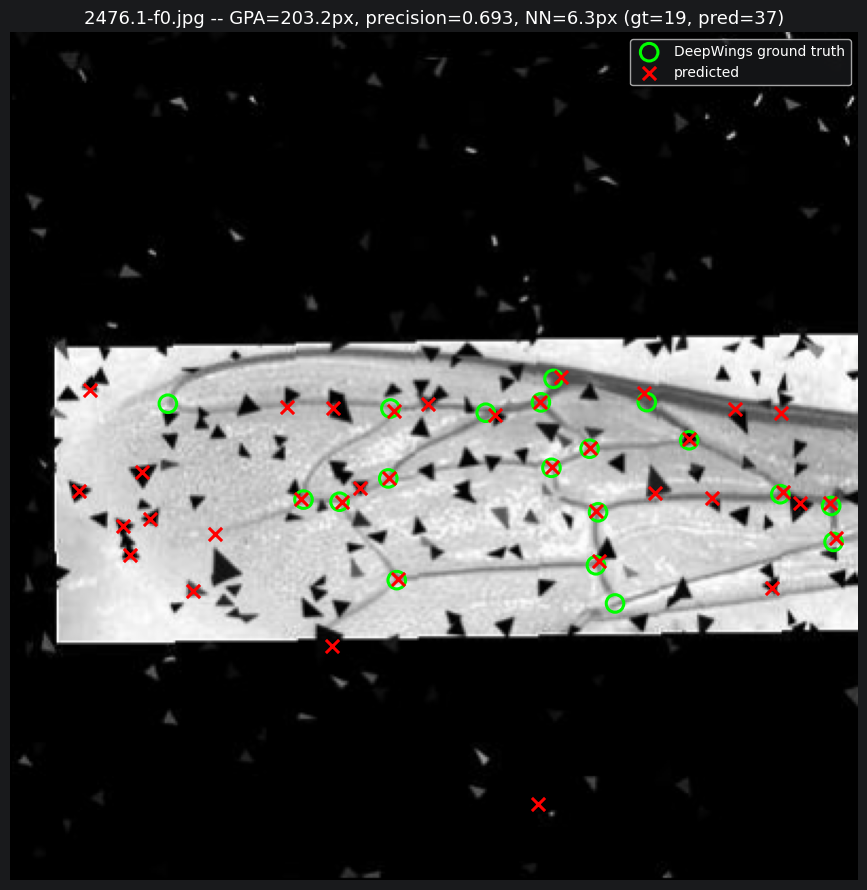

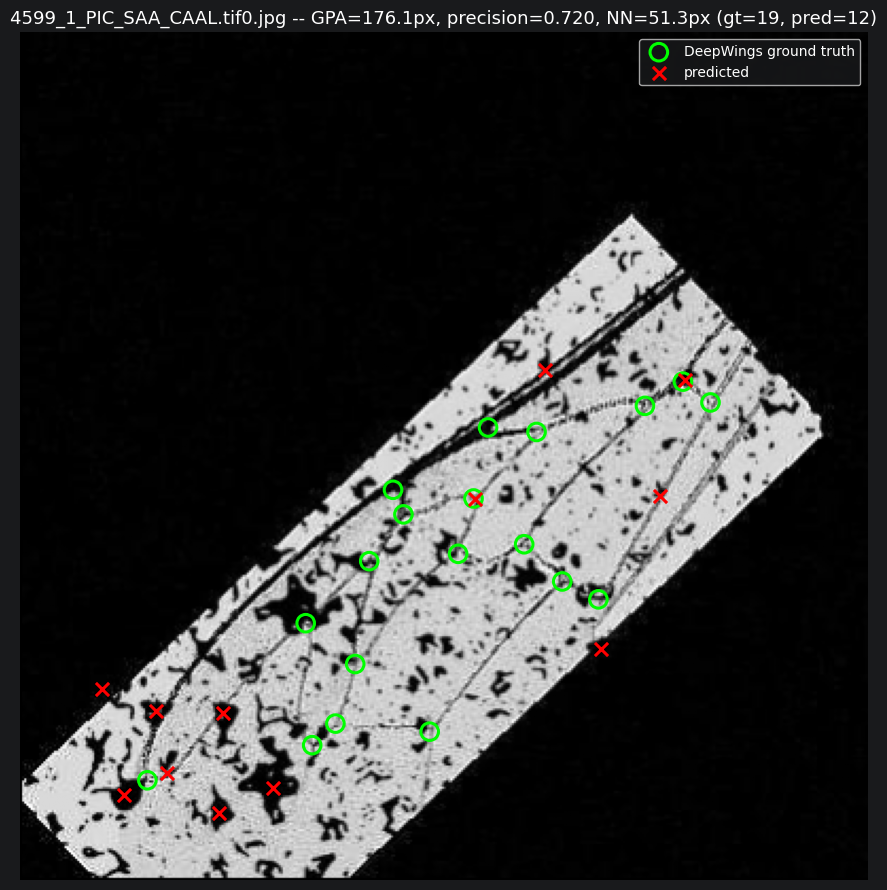

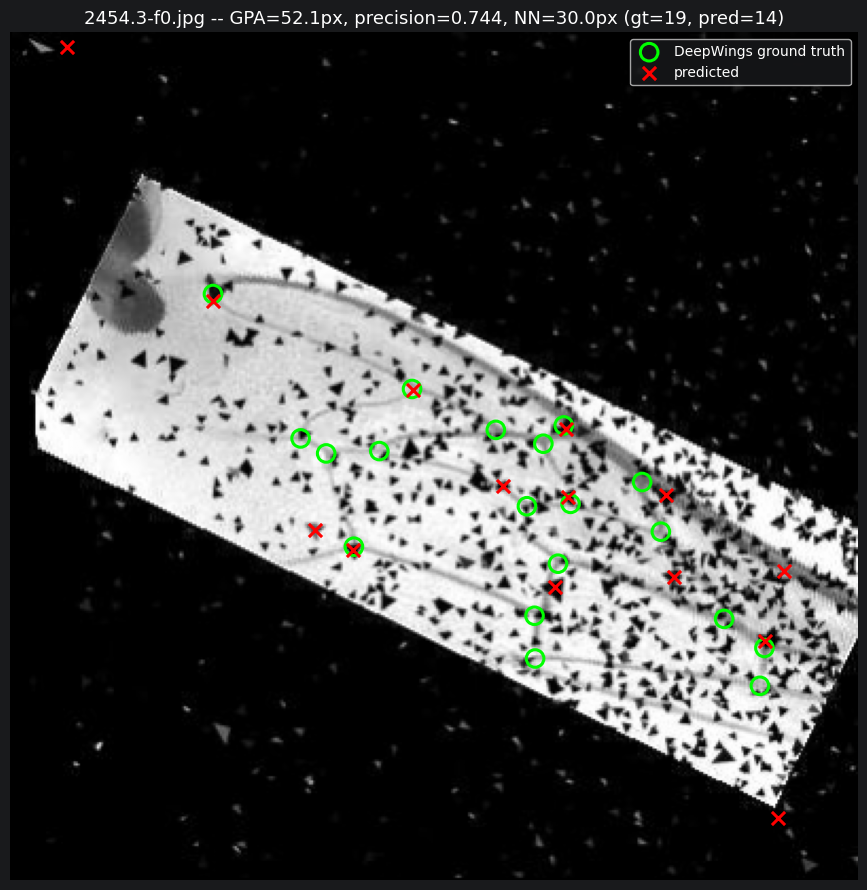

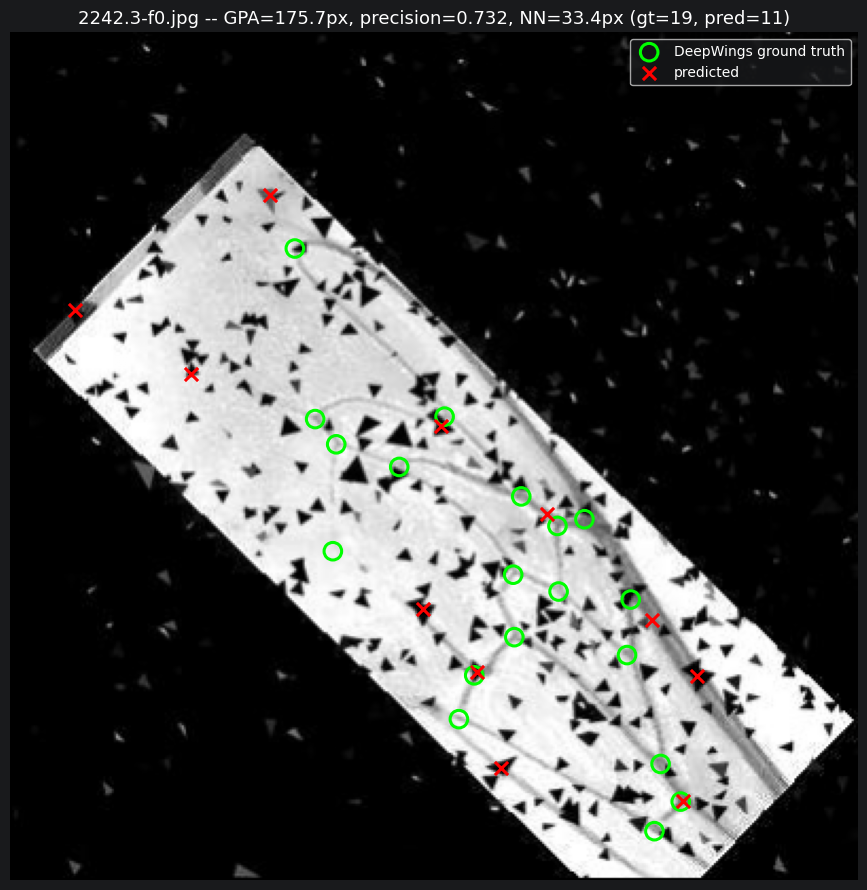

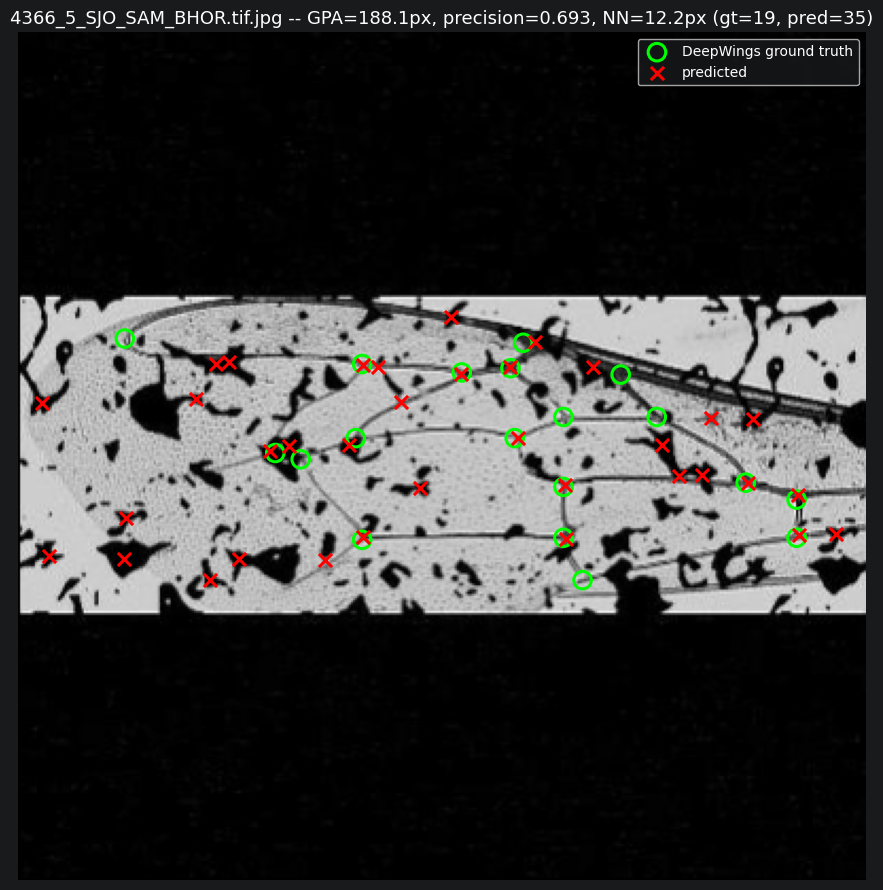

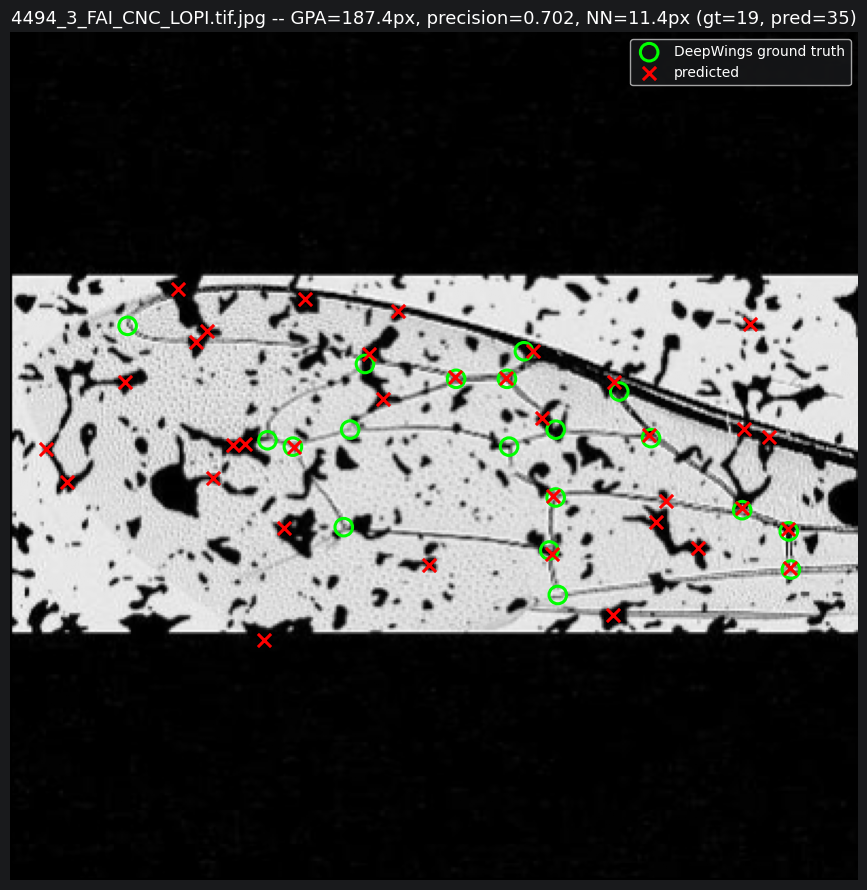

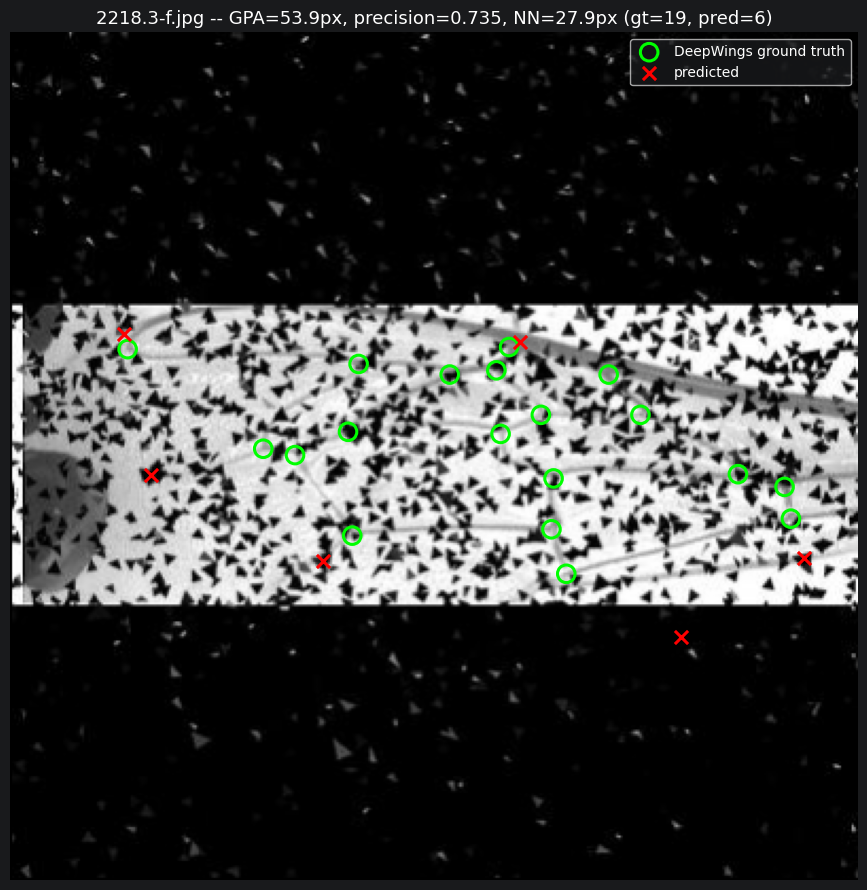

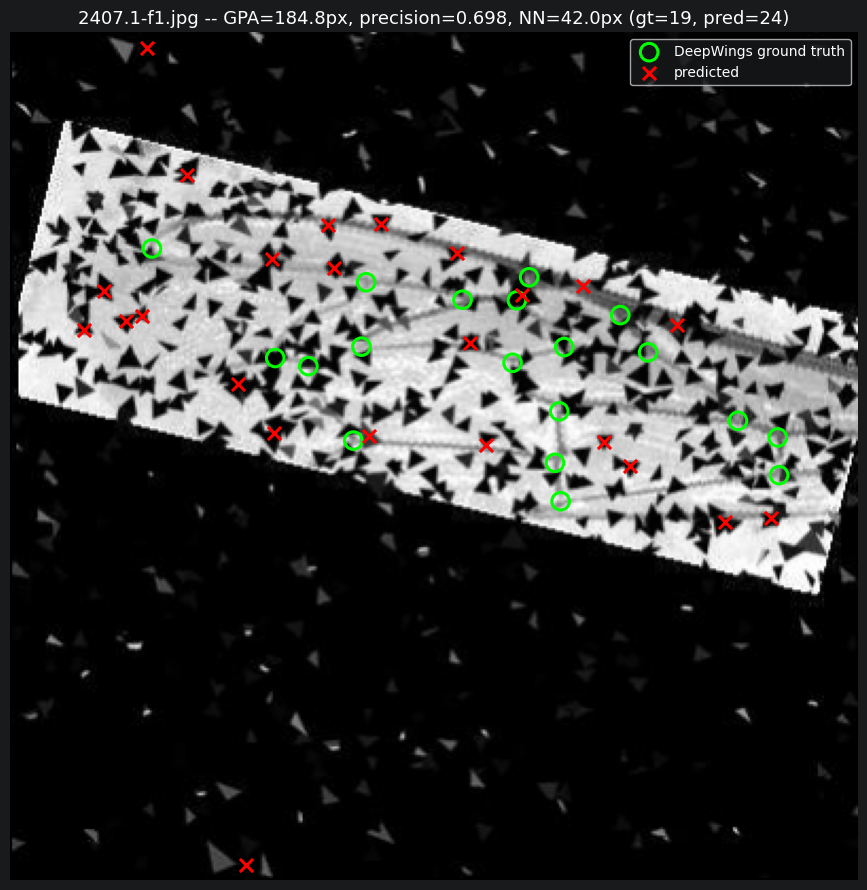

In [21]:
n_worst = 8
worst = sorted(per_image, key=lambda r: r["gpa_mean"], reverse=True)[:n_worst]

for r in worst:
    result = evaluate_pair(r["path"], r["mask_path"])
    show_one(result["image"], result["pred_coords"], result["gt_coords"], result_title(r["path"].name, result))

## Section F -- interactive: re-run for a new random example

**Just re-run this cell** repeatedly -- each execution picks a different
random DeepWings test image and shows the overlay with both accuracy
numbers.

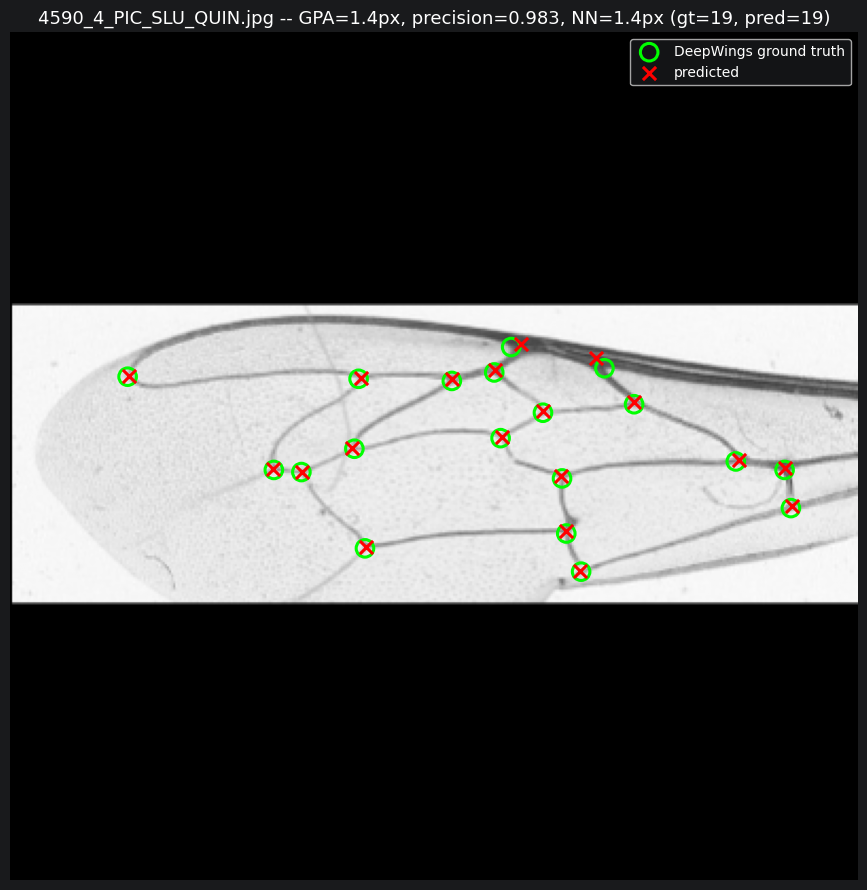

In [22]:
path, mask_path = random.choice(pairs)
result = evaluate_pair(path, mask_path)
show_one(result["image"], result["pred_coords"], result["gt_coords"], result_title(path.name, result))

## Summary

- Section A/B: sanity-checks the DeepWings preprocessing itself (the
  horizontal flip) before trusting any accuracy number built on top of it.
- Section C is the headline result: GPA-ordered pixel accuracy (production-
  realistic -- see intro) *and* DeepWings' own positional-precision score
  (`wing_positional_precision`, notebook 20, paper value 0.943) across the
  whole DeepWings test set -- both as the literal number (matching how our
  own in-domain metrics/notebook 20 are computed, for a fair comparison) and
  restricted to the subset with a plausible predicted point count (isolating
  landmark-accuracy from outright detection failures). Unlike notebook 20's
  own attempt to reproduce 0.943 (which could only compare detections to a
  per-class *consensus* shape, since DeepWings' manual annotations aren't
  shipped in their repo), this notebook has real per-wing manual ground
  truth (`test_masks/`), so it's a more faithful comparison to the paper's
  actual number.
- A GPA-ordered number well above nearest-neighbor here would mean the same
  thing it means in notebook 25: the segmentation itself is fine but GPA's
  ordering step is struggling -- worth checking against `wings/gpa.py`'s
  existing rotation/reflection fixes before assuming it's a new problem.
- Section D/E turn the aggregate into a distribution and let you look
  directly at the worst cases -- a long tail here is expected (DeepWings
  wings vary in species/preservation/photography setup in ways our own
  dataset doesn't), the question is how long.
- Checking a different/future checkpoint later: update `CHECKPOINT_PATH` in
  the Setup cell (and `MODEL_SIGMOID` if it uses a WeightedDiceLoss-style
  config like 1/3 instead of BCEDiceLoss like 4).